In [ ]:
%pip install python-dotenv
%pip install roboflow
%pip install ultralytics

In [ ]:
#Loading and setting the APIkey from environment variables
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("ROBOFLOW_API_KEY")

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=api_key)
project = rf.workspace("builderformer").project("builderformer-4")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import torch
import torchvision

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

device = '0' if torch.cuda.is_available() else 'cpu'

PyTorch version: 2.6.0+cu126
Torchvision version: 0.21.0+cu126
CUDA available: True
CUDA version: 12.6


In [ ]:
from ultralytics import YOLO

#model = YOLO('C:/Users/Linos/Documents/Coding_practice/Dirbtinis Intelektas ir Python/Intelligent-Architecture/runs/detect/train5/weights/last.pt')

data_path = os.path.join(dataset.location, 'data.yaml')

model_small = YOLO('yolov8s.pt')
model_small.train(data=data_path, epochs=50, imgsz=640, plots=True, device=device)

New https://pypi.org/project/ultralytics/8.3.85 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.83  Python-3.12.7 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\weights\last.pt, data=c:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=C:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\weights\last.pt, amp=True, fraction=1.0, profile=False, freeze=Non

train: Scanning C:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\train\labels.cache... 1378 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1378/1378 [00:00<?, ?it/s]

train: WARNING  C:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\train\images\APT_FP_SPA_042750254_PNG_jpg.rf.59ee5cecadd0e0849361dc6cf26d57f3.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\train\images\APT_FP_SPA_042750254_PNG_jpg.rf.fcedc71d77f2fbf0c97218713dc44cef.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\train\images\APT_FP_SPA_057472177_PNG_jpg.rf.94c9030690d3802fda56f9e8de333050.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\train\images\APT_FP_SPA_057472177_PNG_jpg.rf.b22a62368b57d85082a90701fa9880a6.jpg: 1 duplicate labels removed



val: Scanning C:\Users\Linos\Documents\Coding_practice\Dirbtinis_Intelektas_ir_Python\Intelligent-Architecture\app\data\BuilderFormer-4-4\valid\labels.cache... 394 images, 0 backgrounds, 0 corrupt: 100%|██████████| 394/394 [00:00<?, ?it/s]


Plotting labels to c:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000556, momentum=0.9) with parameter groups 97 weight(decay=0.0), 104 weight(decay=0.0005), 103 bias(decay=0.0)
Resuming training C:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\weights\last.pt from epoch 47 to 50 total epochs
Closing dataloader mosaic
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to c:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        394      19822      0.936      0.872      0.921      0.838



4 epochs completed in 1.627 hours.
Optimizer stripped from c:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\weights\last.pt, 87.7MB
Optimizer stripped from c:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\weights\best.pt, 87.7MB

Validating c:\Users\Linos\Documents\Coding_practice\Dirbtinis Intelektas ir Python\Intelligent-Architecture\runs\detect\train5\weights\best.pt...
Ultralytics 8.3.83  Python-3.12.7 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
Model summary (fused): 112 layers, 43,617,402 parameters, 0 gradients, 164.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:26<00:00,  2.07s/it]


                   all        394      19822      0.936      0.871      0.921      0.838
            background        394        394      0.975      0.997      0.993      0.986
         space_balconi        318       1692      0.933      0.933      0.962       0.88
         space_bedroom        375       2985      0.969      0.975      0.981      0.953
       space_dressroom        299        822      0.922      0.892      0.937      0.846
        space_elevator        174        362      0.977      0.887      0.967      0.851
   space_elevator_hall        199        384      0.946      0.916      0.963       0.89
           space_front        365       1083      0.975      0.899       0.96      0.812
         space_kitchen        366       1036      0.959      0.913      0.955      0.888
     space_living_room        372       1001       0.96       0.95      0.976      0.927
space_multipurpose_space         98        134      0.782      0.649      0.698      0.651
           space_ot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E3A200F530>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,   

In [ ]:
model_small = YOLO('yolov8s.pt')
model_small.train(data=data_path, epochs=100, imgsz=640, plots=True, device=device)

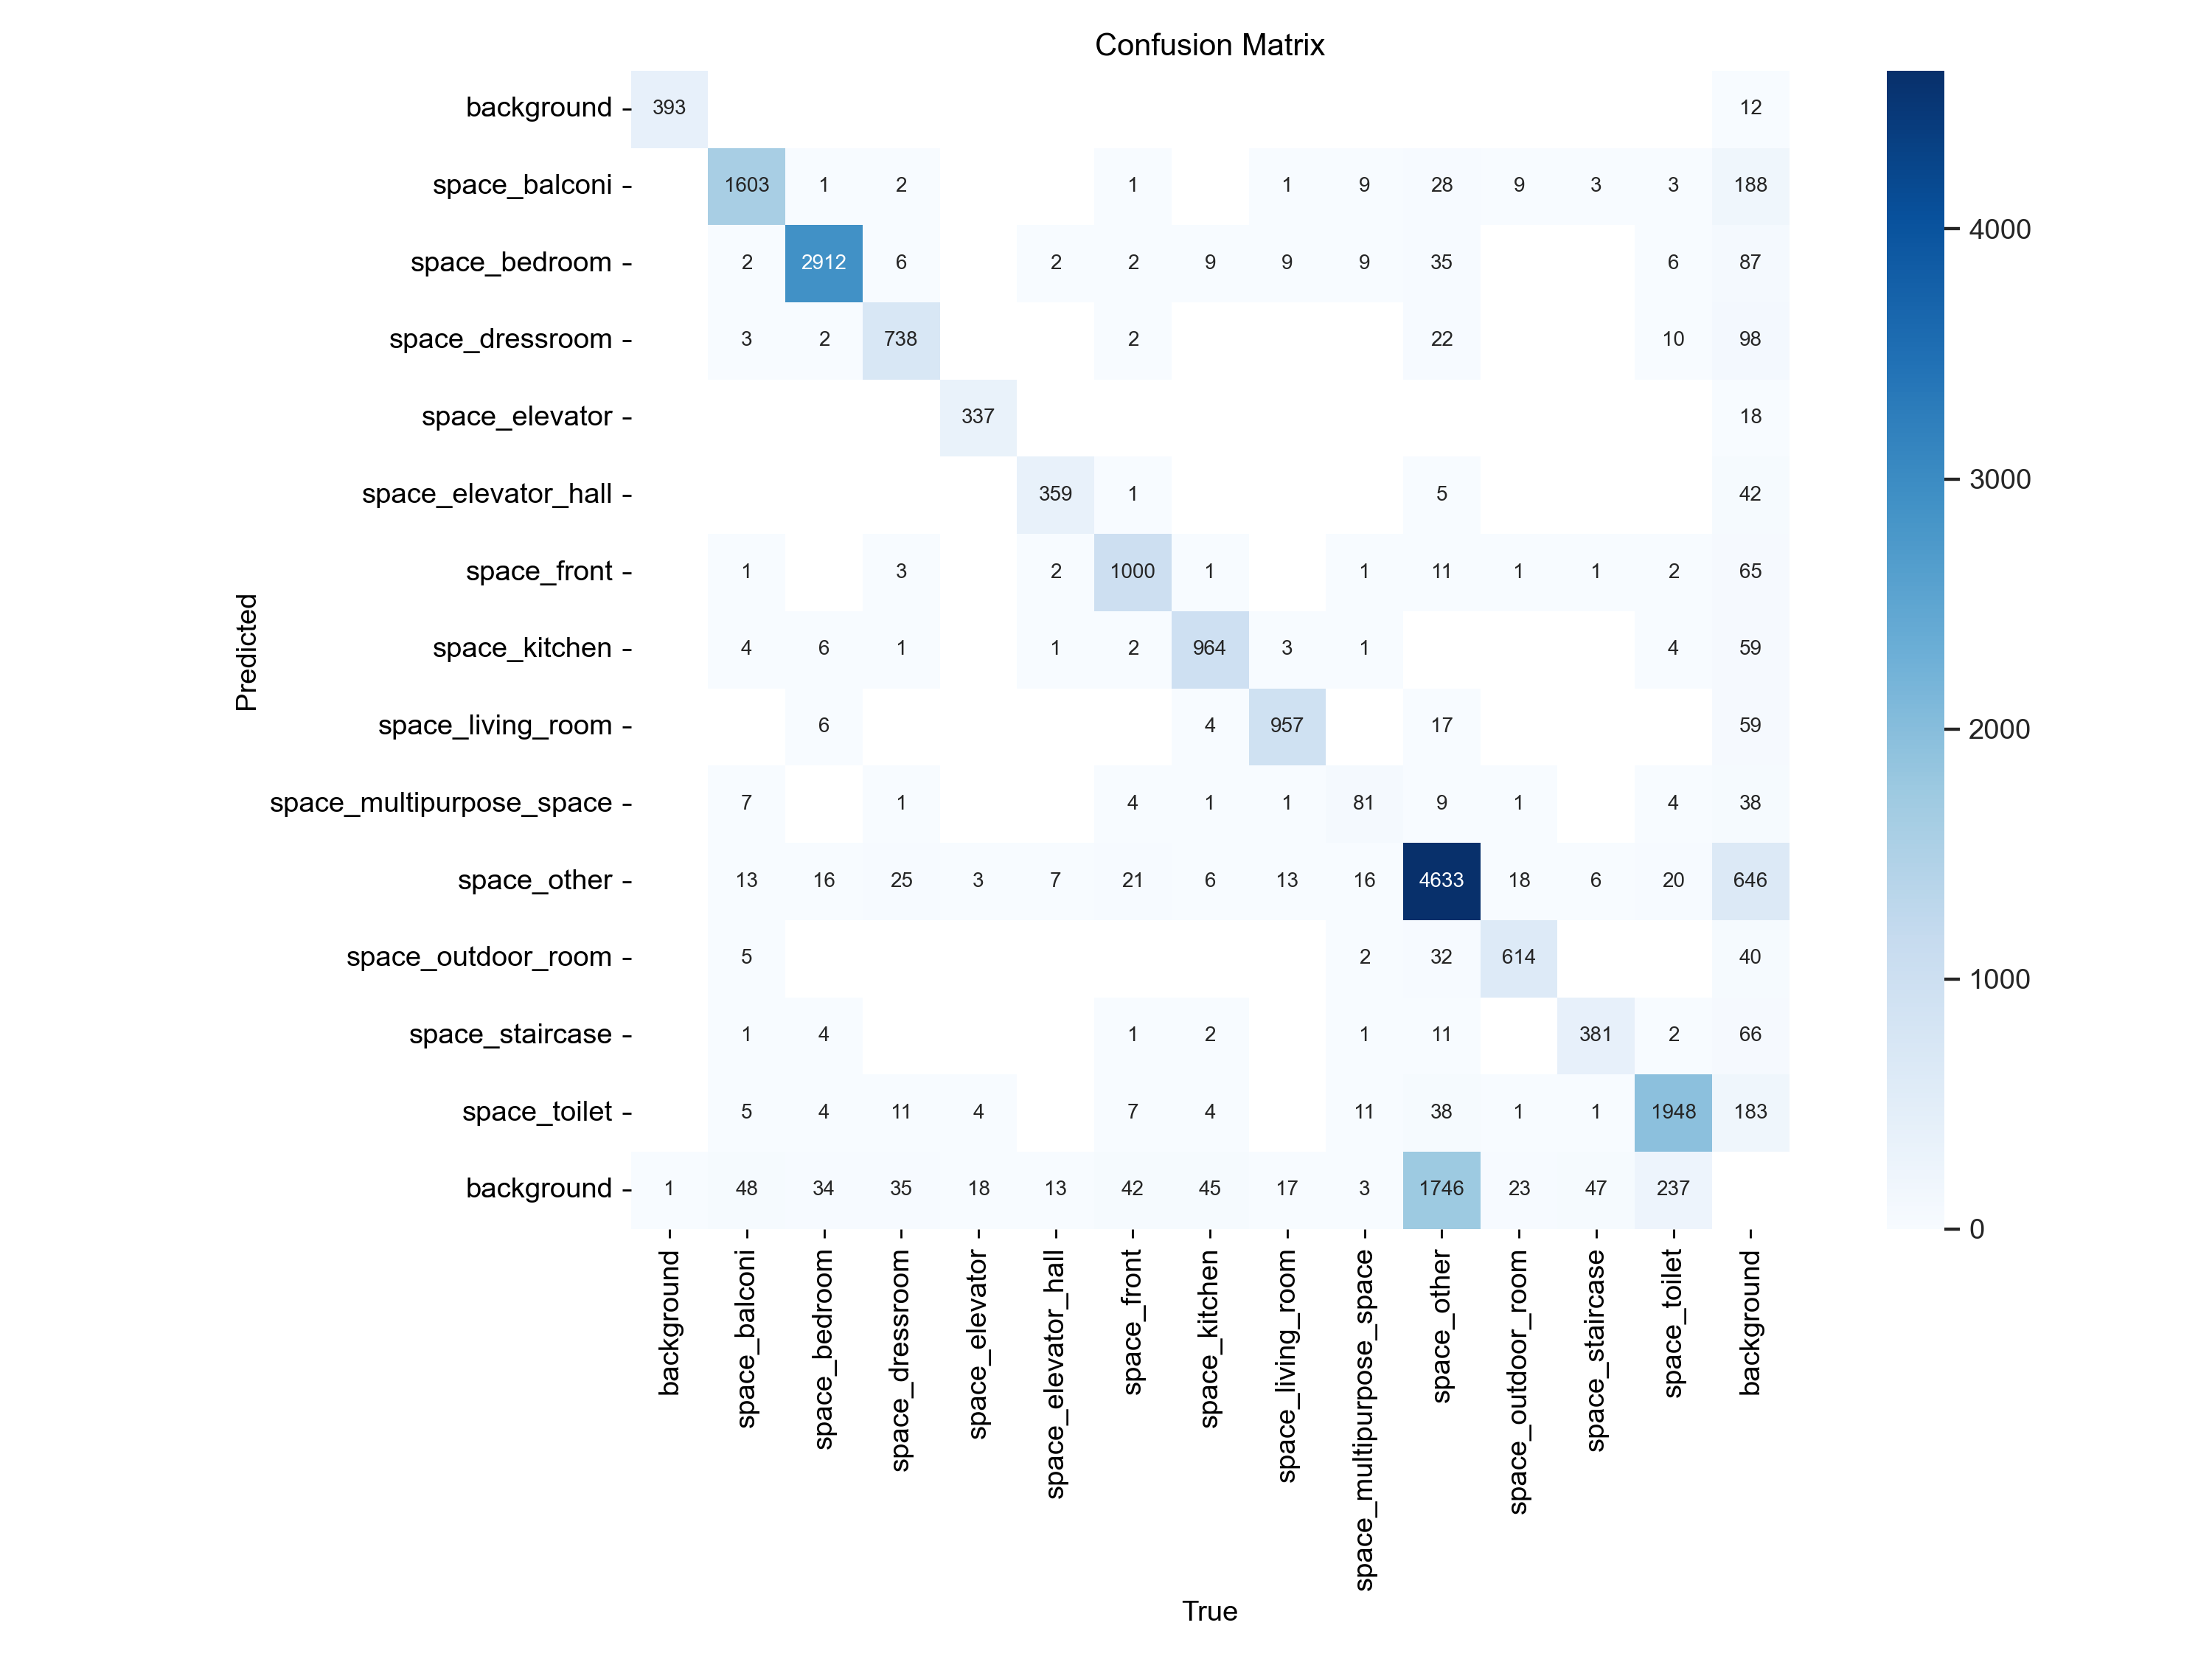

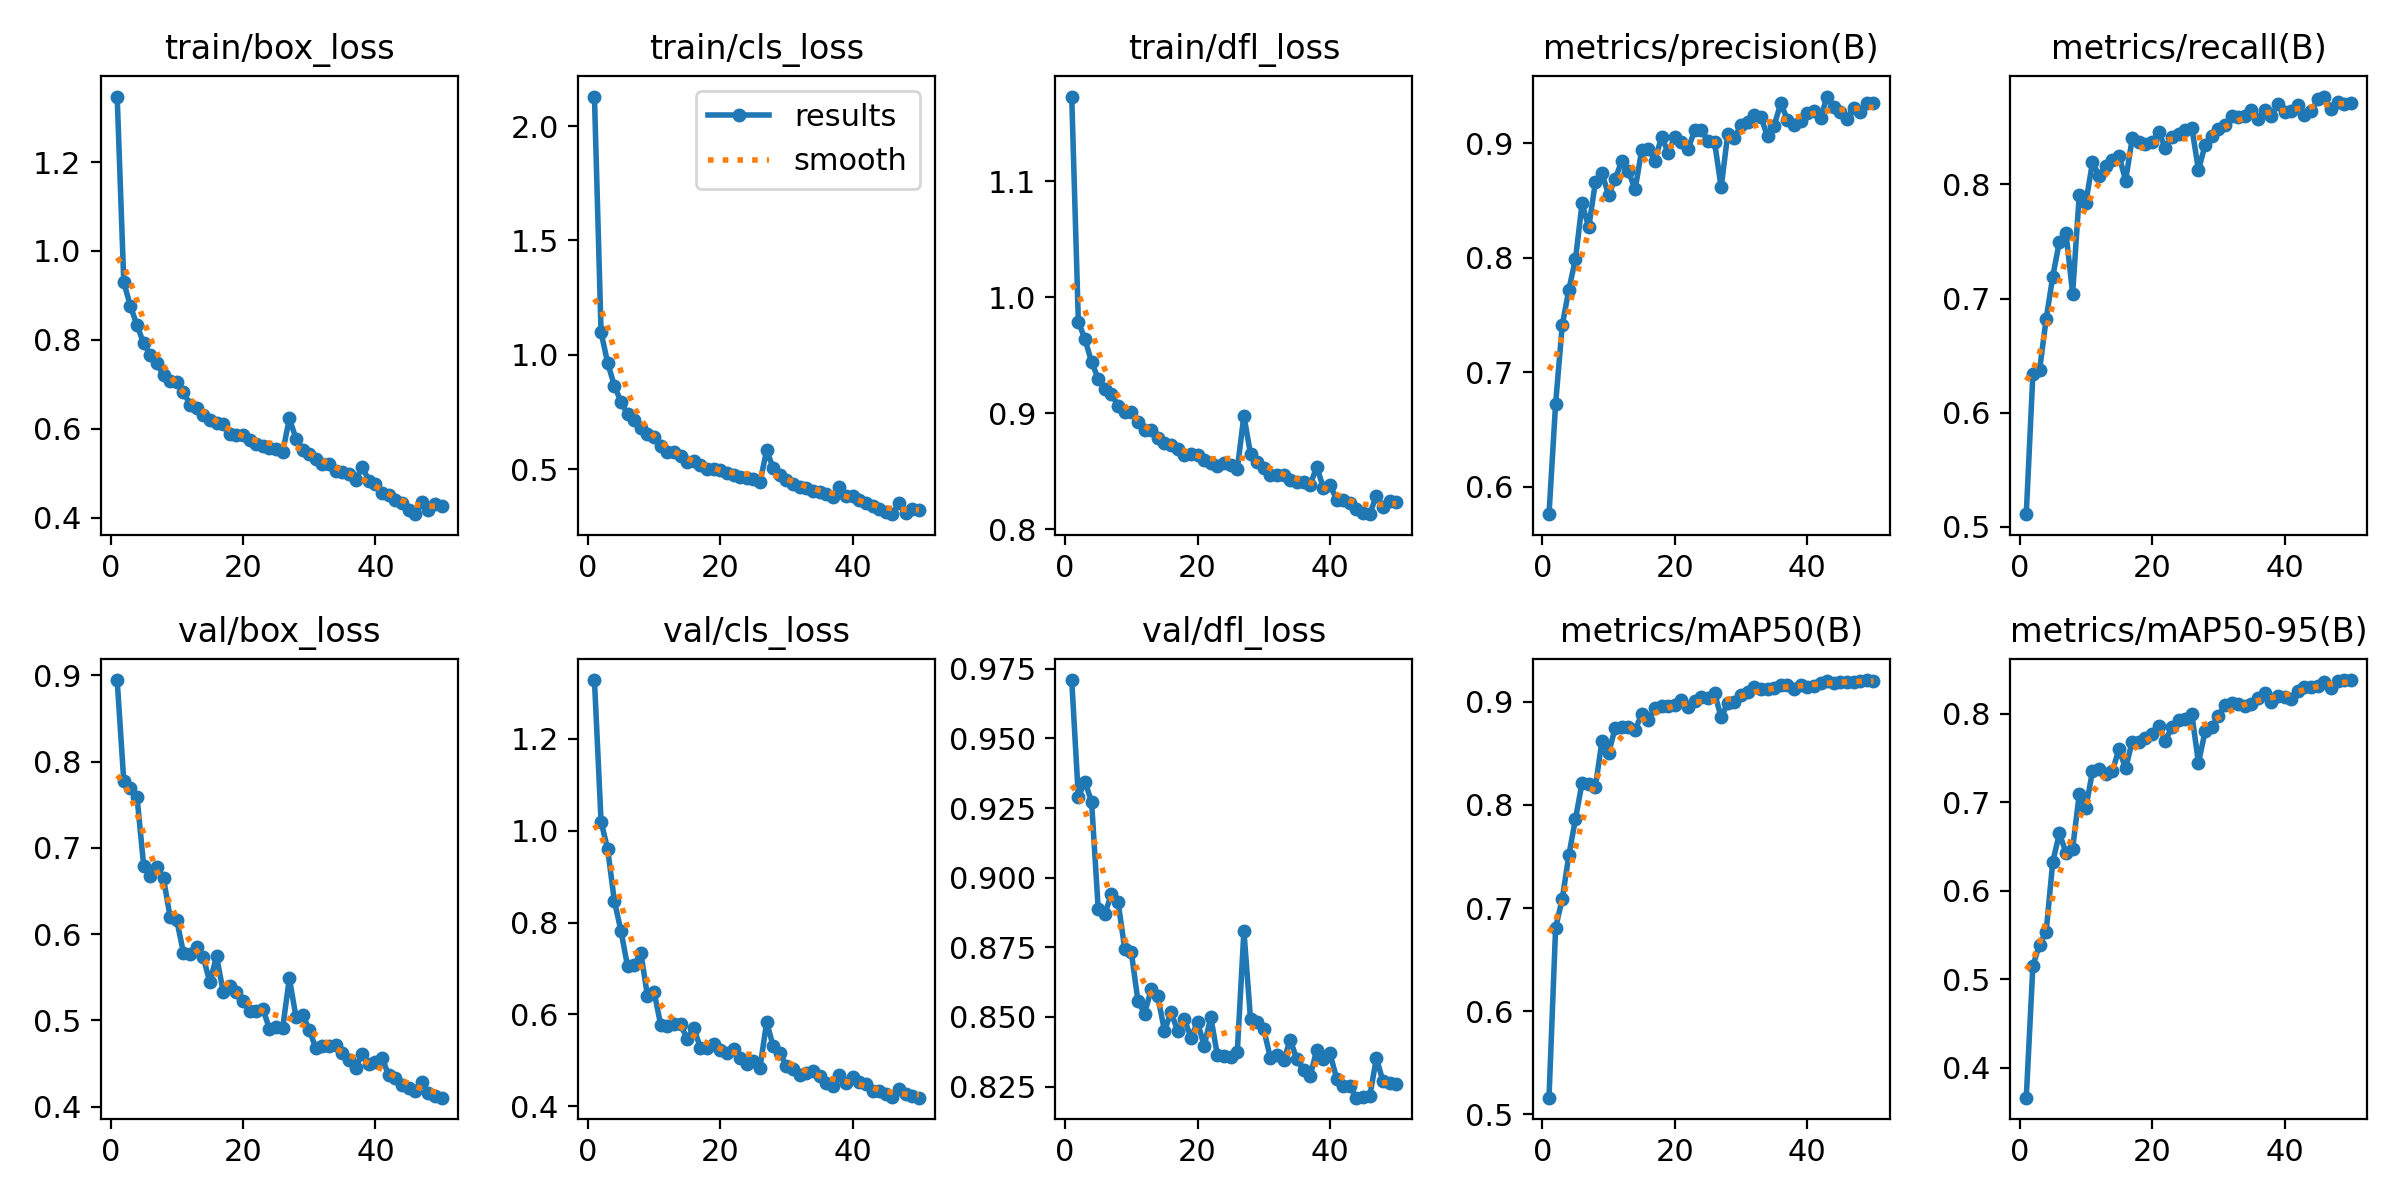

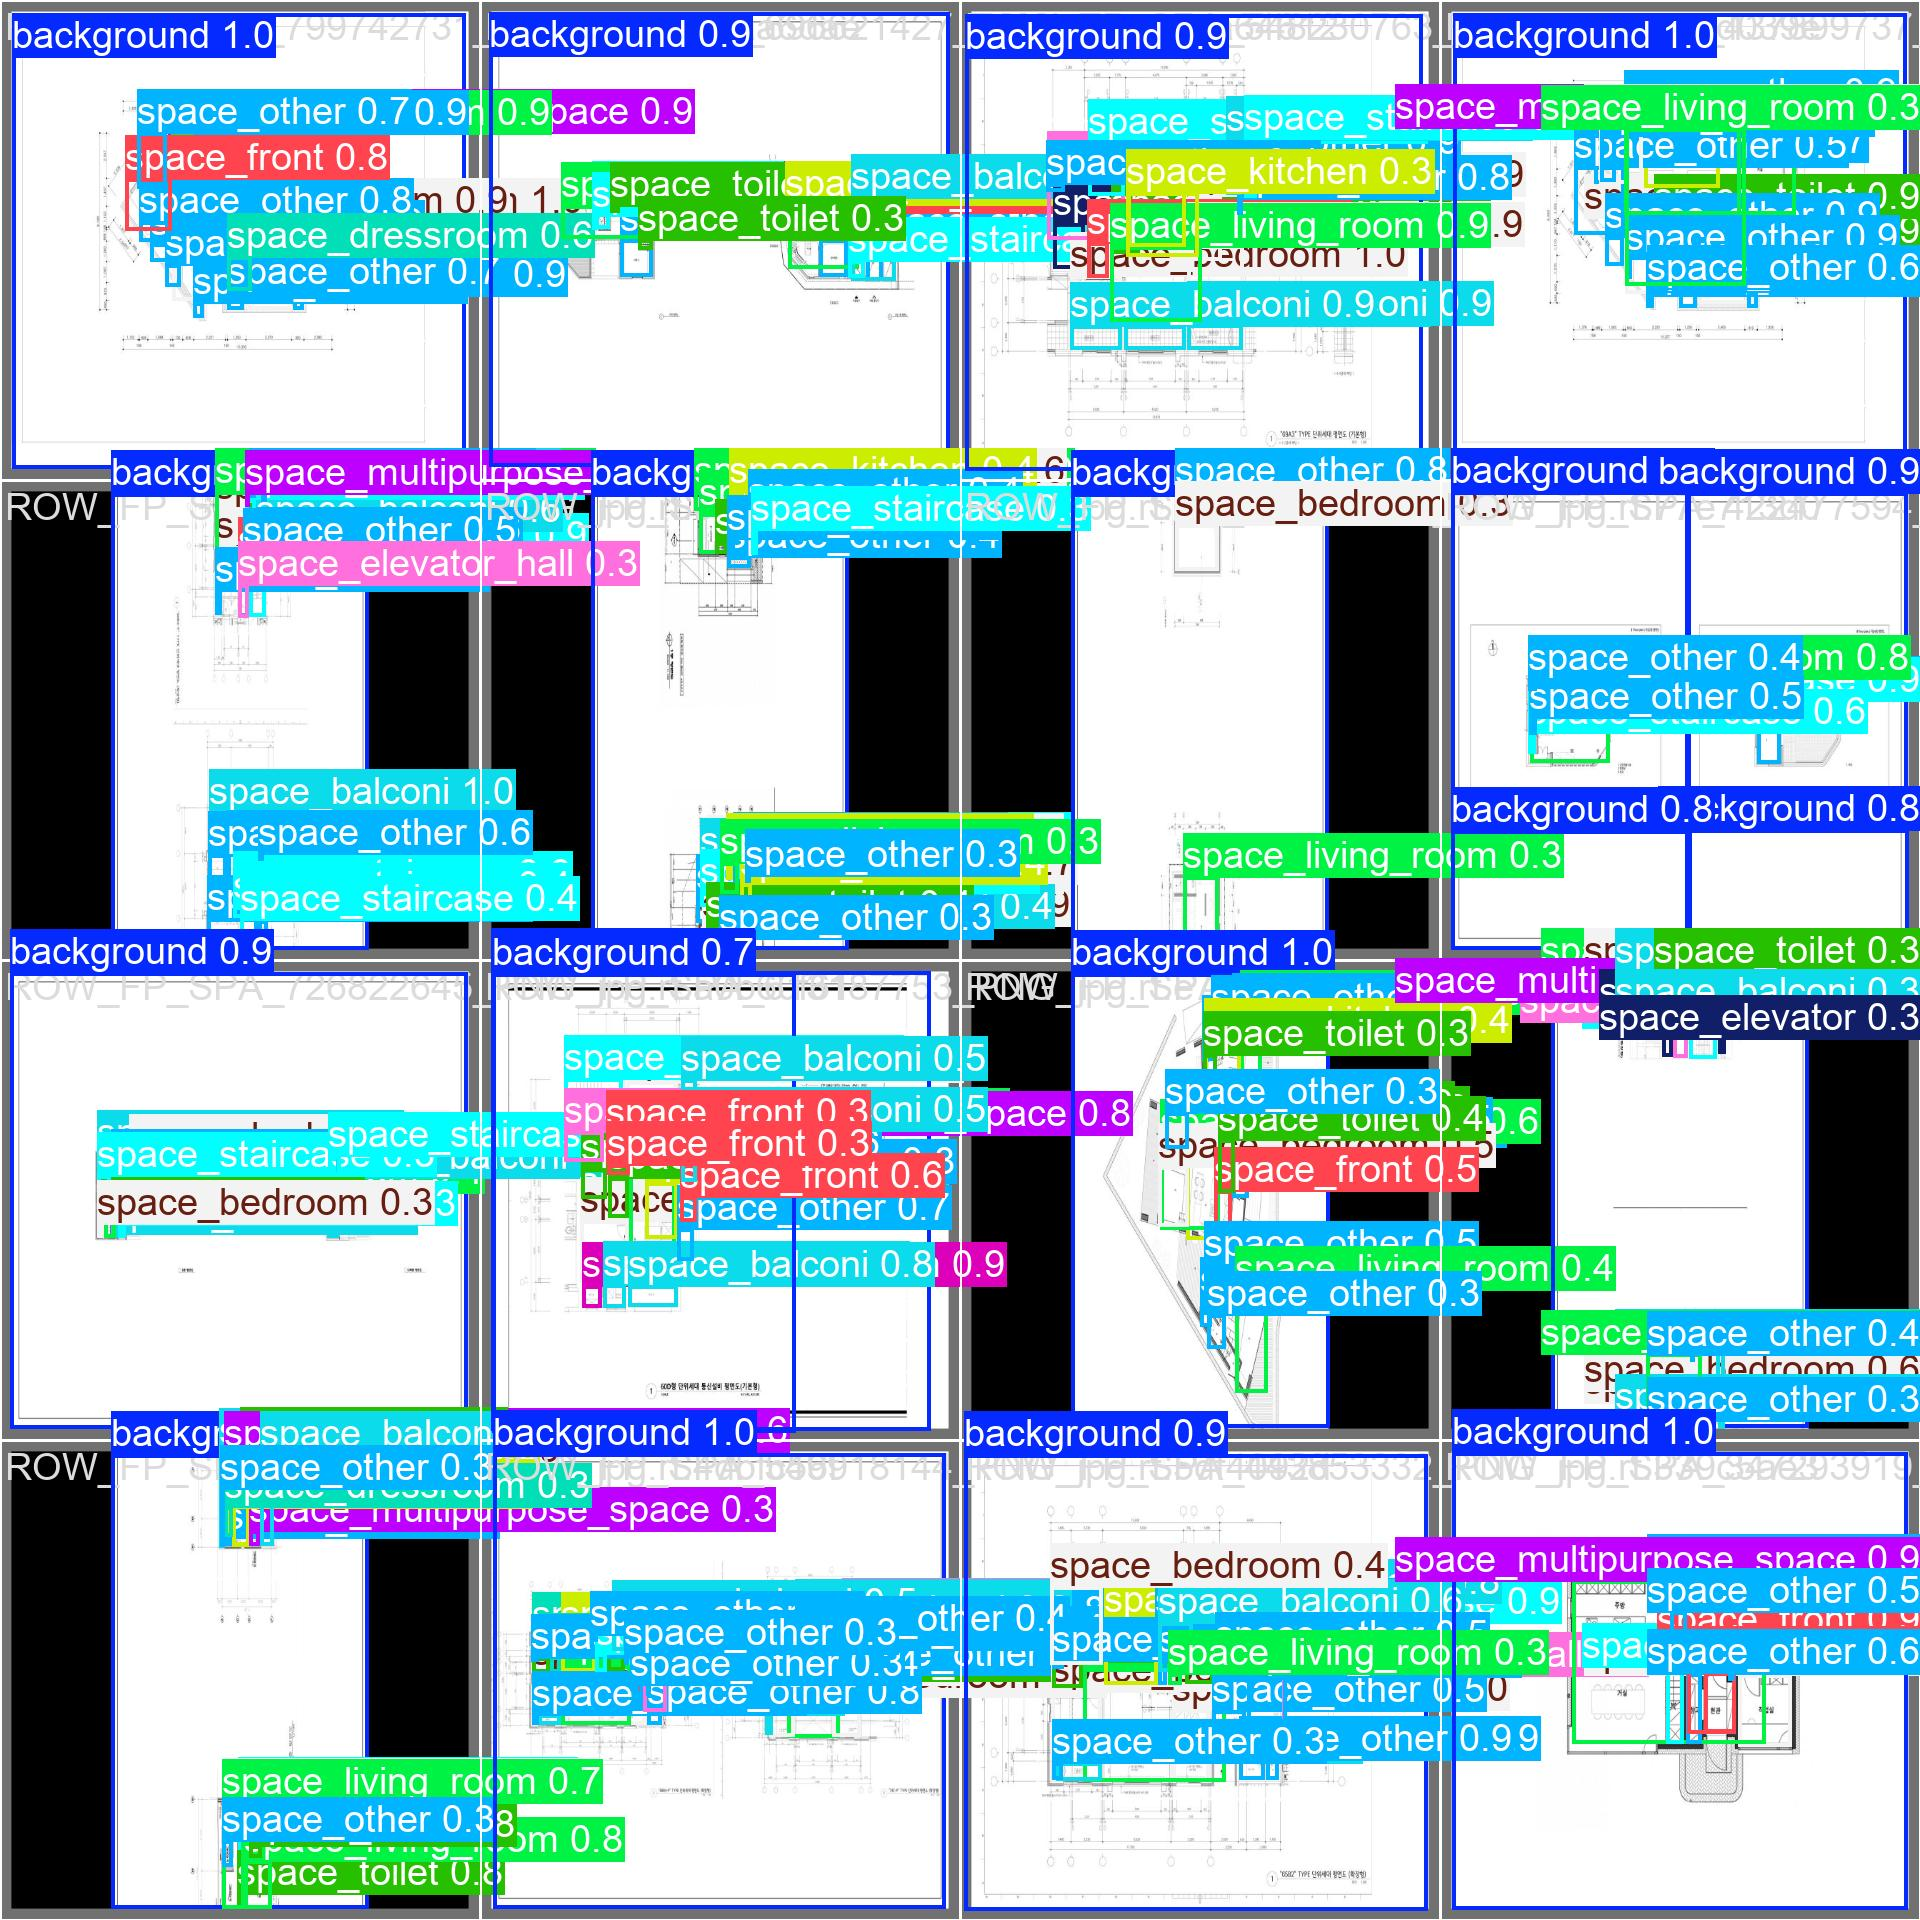

In [ ]:
from IPython.display import display, Image

link_prefix = 'C:/Users/Linos/Documents/Coding_practice/Dirbtinis Intelektas ir Python/Intelligent-Architecture/runs/detect/train5/'

display(Image(filename=link_prefix + 'confusion_matrix.png'))
display(Image(filename=link_prefix + 'results.png'))
display(Image(filename=link_prefix + 'val_batch0_pred.jpg'))